# EDA 15.4: Returns, Product, Promotion, and Size Analysis

This notebook analyzes how returns relate to products, promotions, discount level, size, category, and return reason, with emphasis on business recommendations and lagged return/refund signals for net-Revenue forecasting.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['returns.csv', 'order_items.csv', 'products.csv', 'promotions.csv', 'orders.csv', 'sales.csv', 'payments.csv']
REQUIRED = {'returns.csv', 'order_items.csv', 'products.csv', 'promotions.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,order_items.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,products.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,promotions.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
4,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
6,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...


## 2. Load Returns, Order Items, Products, Promotions, and Optional Files

Load all available inputs safely with pandas and display schema summaries.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
returns = data.get('returns')
order_items = data.get('order_items')
products = data.get('products')
promotions = data.get('promotions')
orders = data.get('orders')
sales = data.get('sales')
payments = data.get('payments')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,returns,True,39939,"return_id, order_id, product_id, return_date, ..."
1,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
2,products,True,2412,"product_id, product_name, category, segment, s..."
3,promotions,True,50,"promo_id, promo_name, promo_type, discount_val..."
4,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
5,sales,True,3833,"Date, Revenue, COGS"
6,payments,True,646945,"order_id, payment_method, payment_value, insta..."


## 3. Identify Return, Order Item, Product, Promotion, Discount, Size, Category, Revenue, and Date Columns

Use tolerant matching for likely naming variations and create fallback promo indicators from discount activity where necessary.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

return_cols = {}
if returns is not None:
    return_cols = {
        'return_id': find_column(returns.columns, ['return_id', 'id'], contains=True),
        'order_id': find_column(returns.columns, ['order_id']),
        'product_id': find_column(returns.columns, ['product_id']),
        'customer_id': find_column(returns.columns, ['customer_id'], contains=True),
        'return_date': find_column(returns.columns, ['return_date', 'date'], contains=True),
        'return_reason': find_column(returns.columns, ['return_reason', 'reason_code', 'reason'], contains=True),
        'return_quantity': find_column(returns.columns, ['return_quantity', 'quantity_returned', 'qty'], contains=True),
        'refund_amount': find_column(returns.columns, ['refund_amount', 'refund', 'refund_value'], contains=True),
    }

item_cols = {}
if order_items is not None:
    item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'unit_price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount_amount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
        'item_revenue': find_column(order_items.columns, ['item_total', 'line_total', 'revenue', 'sales_amount', 'net_sales'], contains=True),
        'promo_id': find_column(order_items.columns, ['promo_id', 'promotion_id', 'campaign_id', 'coupon_id', 'discount_id'], contains=True),
        'promo_id_2': find_column(order_items.columns, ['promo_id_2']),
    }

product_cols = {}
if products is not None:
    product_cols = {
        'product_id': find_column(products.columns, ['product_id']),
        'product_name': find_column(products.columns, ['product_name', 'name', 'title'], contains=True),
        'category': find_column(products.columns, ['category']),
        'size': find_column(products.columns, ['size']),
        'segment': find_column(products.columns, ['segment']),
    }

promo_cols = {}
if promotions is not None:
    promo_cols = {
        'promo_id': find_column(promotions.columns, ['promo_id', 'promotion_id', 'campaign_id'], contains=True),
        'promo_type': find_column(promotions.columns, ['promo_type', 'promotion_type', 'type'], contains=True),
        'discount_value': find_column(promotions.columns, ['discount_value', 'discount_amount', 'discount'], contains=True),
        'start_date': find_column(promotions.columns, ['start_date'], contains=True),
        'end_date': find_column(promotions.columns, ['end_date'], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
    }

identified = pd.DataFrame({
    'returns': pd.Series(return_cols),
    'order_items': pd.Series(item_cols),
    'products': pd.Series(product_cols),
    'promotions': pd.Series(promo_cols),
    'orders': pd.Series(orders_cols),
})
display(identified)

,returns,order_items,products,promotions,orders
category,NaN,NaN,category,NaN,NaN
customer_id,None,NaN,NaN,NaN,NaN
discount_amount,NaN,discount_amount,NaN,NaN,NaN
discount_value,NaN,NaN,NaN,discount_value,NaN
end_date,NaN,NaN,NaN,end_date,NaN
item_revenue,NaN,None,NaN,NaN,NaN
order_date,NaN,NaN,NaN,NaN,order_date
order_id,order_id,order_id,NaN,NaN,order_id
order_status,NaN,NaN,NaN,NaN,order_status
product_id,product_id,product_id,product_id,NaN,NaN


## 4. Return Data Quality Checks

Standardize return reasons and inspect missingness, duplicates, and key-field quality.

In [4]:
return_warnings = []
returns_clean = None

def standardize_reason(value):
    if pd.isna(value):
        return np.nan
    raw = str(value).strip().lower()
    raw = raw.replace('-', '_').replace(' ', '_')
    replacements = {
        'wrong_size': 'wrong_size',
        'size_issue': 'wrong_size',
        'too_small': 'wrong_size',
        'too_large': 'wrong_size',
        'fit_issue': 'wrong_size',
        'changed_mind': 'changed_mind',
        'changedmind': 'changed_mind',
        'no_longer_needed': 'changed_mind',
        'buyer_remorse': 'changed_mind',
        'did_not_want': 'changed_mind',
        'late_delivery': 'late_delivery',
        'not_as_described': 'not_as_described',
        'defective': 'defective',
        'damaged': 'defective',
        'faulty': 'defective',
    }
    return replacements.get(raw, raw)

if returns is not None:
    returns_clean = returns.copy()
    returns_clean['return_id_std'] = returns_clean[return_cols['return_id']] if return_cols.get('return_id') else pd.NA
    returns_clean['order_id_std'] = returns_clean[return_cols['order_id']] if return_cols.get('order_id') else pd.NA
    returns_clean['product_id_std'] = returns_clean[return_cols['product_id']] if return_cols.get('product_id') else pd.NA
    returns_clean['return_date_std'] = pd.to_datetime(returns_clean[return_cols['return_date']], errors='coerce') if return_cols.get('return_date') else pd.NaT
    returns_clean['return_reason_std'] = returns_clean[return_cols['return_reason']].map(standardize_reason) if return_cols.get('return_reason') else np.nan
    returns_clean['returned_quantity_std'] = pd.to_numeric(returns_clean[return_cols['return_quantity']], errors='coerce') if return_cols.get('return_quantity') else np.nan
    returns_clean['refund_amount_std'] = pd.to_numeric(returns_clean[return_cols['refund_amount']], errors='coerce') if return_cols.get('refund_amount') else np.nan

    dup_cols = ['return_id_std'] if returns_clean['return_id_std'].notna().any() else ['order_id_std', 'product_id_std', 'return_date_std']
    quality = pd.DataFrame([{
        'return_rows': len(returns_clean),
        'return_date_start': returns_clean['return_date_std'].min(),
        'return_date_end': returns_clean['return_date_std'].max(),
        'missing_return_dates': int(returns_clean['return_date_std'].isna().sum()),
        'missing_order_ids': int(returns_clean['order_id_std'].isna().sum()),
        'missing_product_ids': int(returns_clean['product_id_std'].isna().sum()),
        'missing_return_reasons': int(returns_clean['return_reason_std'].isna().sum()),
        'missing_returned_quantities': int(returns_clean['returned_quantity_std'].isna().sum()),
        'missing_refund_amounts': int(returns_clean['refund_amount_std'].isna().sum()),
        'duplicate_return_records': int(returns_clean.duplicated(subset=dup_cols).sum()),
    }])
    display(quality)
    if returns_clean['return_reason_std'].notna().any():
        display(returns_clean['return_reason_std'].value_counts(dropna=False).rename_axis('return_reason').reset_index(name='count'))
else:
    warnings.warn('returns.csv unavailable.')

,return_rows,return_date_start,return_date_end,missing_return_dates,missing_order_ids,missing_product_ids,missing_return_reasons,missing_returned_quantities,missing_refund_amounts,duplicate_return_records
0,39939,2012-07-11,2022-12-31,0,0,0,0,0,0,0


,return_reason,count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


## 5. Build Return-Enriched Item Dataset

Build an item-level dataset by joining order items to products, returns, promotions, and optionally orders for order date. Exact `order_id + product_id` matching is preferred.

In [5]:
items_enriched = pd.DataFrame()

if order_items is not None:
    items = order_items.copy()
    items['order_id_std'] = items[item_cols['order_id']] if item_cols.get('order_id') else pd.NA
    items['product_id_std'] = items[item_cols['product_id']] if item_cols.get('product_id') else pd.NA
    items['ordered_quantity'] = pd.to_numeric(items[item_cols['quantity']], errors='coerce') if item_cols.get('quantity') else np.nan
    items['unit_price_std'] = pd.to_numeric(items[item_cols['unit_price']], errors='coerce') if item_cols.get('unit_price') else np.nan
    items['discount_amount_std'] = pd.to_numeric(items[item_cols['discount_amount']], errors='coerce').fillna(0) if item_cols.get('discount_amount') else 0
    if item_cols.get('item_revenue'):
        items['item_revenue_std'] = pd.to_numeric(items[item_cols['item_revenue']], errors='coerce')
    else:
        items['item_revenue_std'] = items['ordered_quantity'] * items['unit_price_std']
    gross_before_discount = items['ordered_quantity'] * items['unit_price_std']
    items['discount_rate_std'] = np.where(gross_before_discount > 0, items['discount_amount_std'] / gross_before_discount, np.nan)
    items['promo_id_std'] = items[item_cols['promo_id']] if item_cols.get('promo_id') else pd.NA
    if item_cols.get('promo_id_2'):
        items['promo_id_std'] = items['promo_id_std'].fillna(items[item_cols['promo_id_2']])
    items['promo_used'] = items['promo_id_std'].notna() | items['discount_amount_std'].gt(0)

    if products is not None and product_cols.get('product_id'):
        prod_cols = [product_cols['product_id']]
        rename_map = {product_cols['product_id']: 'product_id_std'}
        for key in ['product_name', 'category', 'size', 'segment']:
            if product_cols.get(key):
                prod_cols.append(product_cols[key])
                rename_map[product_cols[key]] = key
        prod = products[prod_cols].rename(columns=rename_map)
        items = items.merge(prod, on='product_id_std', how='left', indicator='product_merge')
    else:
        items['product_merge'] = 'left_only'

    if returns_clean is not None and return_cols.get('order_id') and return_cols.get('product_id'):
        ret_item = returns_clean.groupby(['order_id_std', 'product_id_std']).agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            refund_amount=('refund_amount_std', 'sum'),
            return_count=('order_id_std', 'size'),
            return_reason_std=('return_reason_std', lambda s: s.mode().iloc[0] if not s.mode().empty else s.dropna().iloc[0] if s.dropna().any() else np.nan),
            return_date_std=('return_date_std', 'min'),
        ).reset_index()
        items = items.merge(ret_item, on=['order_id_std', 'product_id_std'], how='left', indicator='return_merge')
        match_strategy = 'Exact order_id + product_id'
    elif returns_clean is not None and return_cols.get('order_id'):
        ret_order = returns_clean.groupby('order_id_std').agg(
            returned_quantity=('returned_quantity_std', 'sum'),
            refund_amount=('refund_amount_std', 'sum'),
            return_count=('order_id_std', 'size'),
            return_reason_std=('return_reason_std', lambda s: s.mode().iloc[0] if not s.mode().empty else s.dropna().iloc[0] if s.dropna().any() else np.nan),
            return_date_std=('return_date_std', 'min'),
        ).reset_index()
        items = items.merge(ret_order, on='order_id_std', how='left', indicator='return_merge')
        match_strategy = 'Approximate order_id-only'
    else:
        items['return_merge'] = 'left_only'
        match_strategy = 'Unavailable'

    if promotions is not None and promo_cols.get('promo_id'):
        promo_keep = [promo_cols['promo_id']]
        rename_map = {promo_cols['promo_id']: 'promo_id_std'}
        for key in ['promo_type', 'discount_value', 'start_date', 'end_date']:
            if promo_cols.get(key):
                promo_keep.append(promo_cols[key])
                rename_map[promo_cols[key]] = key
        promo_df = promotions[promo_keep].rename(columns=rename_map)
        items = items.merge(promo_df, on='promo_id_std', how='left', indicator='promo_merge')
    else:
        items['promo_merge'] = 'left_only'

    if orders is not None and orders_cols.get('order_id') and orders_cols.get('order_date'):
        ord_keep = [orders_cols['order_id'], orders_cols['order_date']]
        ord_rename = {orders_cols['order_id']: 'order_id_std', orders_cols['order_date']: 'order_date_raw'}
        ord_df = orders[ord_keep].rename(columns=ord_rename)
        items = items.merge(ord_df, on='order_id_std', how='left')
        items['order_date_std'] = pd.to_datetime(items['order_date_raw'], errors='coerce')
    else:
        items['order_date_std'] = pd.NaT

    items['return_indicator'] = items['returned_quantity'].fillna(0).gt(0) | items['refund_amount'].fillna(0).gt(0)
    items['refund_amount'] = items['refund_amount'].fillna(0)
    items['returned_quantity'] = items['returned_quantity'].fillna(0)
    items['refund_to_revenue_ratio'] = np.where(items['item_revenue_std'] > 0, items['refund_amount'] / items['item_revenue_std'], np.nan)
    items['net_revenue_std'] = items['item_revenue_std'] - items['refund_amount']
    items_enriched = items

    join_quality = pd.DataFrame([{
        'return_match_strategy': match_strategy,
        'order_items_matched_to_products': int((items_enriched['product_merge'] == 'both').sum()) if 'product_merge' in items_enriched.columns else 0,
        'order_items_unmatched_to_products': int((items_enriched['product_merge'] == 'left_only').sum()) if 'product_merge' in items_enriched.columns else 0,
        'returns_matched_to_order_items': int((items_enriched['return_merge'] == 'both').sum()) if 'return_merge' in items_enriched.columns else 0,
        'returns_unmatched_to_order_items': int((~returns_clean.set_index(['order_id_std','product_id_std']).index.isin(items_enriched.set_index(['order_id_std','product_id_std']).index)).sum()) if returns_clean is not None and return_cols.get('product_id') else np.nan,
        'promo_ids_matched_to_promotions': int((items_enriched['promo_merge'] == 'both').sum()) if 'promo_merge' in items_enriched.columns else 0,
        'promo_ids_not_found_in_promotions': int((items_enriched['promo_merge'] == 'left_only').sum()) if 'promo_merge' in items_enriched.columns else 0,
    }])
    display(join_quality)
    display(items_enriched.head(10))

,return_match_strategy,order_items_matched_to_products,order_items_unmatched_to_products,returns_matched_to_order_items,returns_unmatched_to_order_items,promo_ids_matched_to_promotions,promo_ids_not_found_in_promotions
0,Exact order_id + product_id,714669,0,39939,0,276316,438353


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_id_std,product_id_std,ordered_quantity,unit_price_std,discount_amount_std,item_revenue_std,discount_rate_std,promo_id_std,promo_used,product_name,category,size,segment,product_merge,returned_quantity,refund_amount,return_count,return_reason_std,return_date_std,return_merge,promo_type,discount_value,start_date,end_date,promo_merge,order_date_raw,order_date_std,return_indicator,refund_to_revenue_ratio,net_revenue_std
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN,1,2400,7,"1,138.2200",0.0000,"7,967.5400",0.0000,NaN,False,VietMotion YY-09,GenZ,S,Trendy,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-04,2012-07-04,False,0.0000,"7,967.5400"
1,2,609,7,"10,166.2500",0.0000,NaN,NaN,2,609,7,"10,166.2500",0.0000,"71,163.7500",0.0000,NaN,False,SaigonFlex UC-74,Streetwear,M,Everyday,both,6.0000,"52,458.0100",1.0000,late_delivery,2012-07-25,both,NaN,NaN,NaN,NaN,left_only,2012-07-04,2012-07-04,True,0.7371,"18,705.7400"
2,3,396,3,"11,220.3300",0.0000,NaN,NaN,3,396,3,"11,220.3300",0.0000,"33,660.9900",0.0000,NaN,False,SaigonFlex UM-01,Streetwear,S,Balanced,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-04,2012-07-04,False,0.0000,"33,660.9900"
3,4,635,5,"10,639.2500",0.0000,NaN,NaN,4,635,5,"10,639.2500",0.0000,"53,196.2500",0.0000,NaN,False,SaigonFlex UC-00,Streetwear,XL,Everyday,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-04,2012-07-04,False,0.0000,"53,196.2500"
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN,6,1935,1,"1,597.8400",0.0000,"1,597.8400",0.0000,NaN,False,UrbanVN RP-10,Outdoor,XL,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"1,597.8400"
5,7,1934,6,"1,633.4900",0.0000,NaN,NaN,7,1934,6,"1,633.4900",0.0000,"9,800.9400",0.0000,NaN,False,UrbanVN RP-09,Outdoor,L,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"9,800.9400"
6,8,1934,6,"1,602.9200",0.0000,NaN,NaN,8,1934,6,"1,602.9200",0.0000,"9,617.5200",0.0000,NaN,False,UrbanVN RP-09,Outdoor,L,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"9,617.5200"
7,8,1935,4,"1,642.5100",0.0000,NaN,NaN,8,1935,4,"1,642.5100",0.0000,"6,570.0400",0.0000,NaN,False,UrbanVN RP-10,Outdoor,XL,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"6,570.0400"
8,9,1432,8,"4,049.6400",0.0000,NaN,NaN,9,1432,8,"4,049.6400",0.0000,"32,397.1200",0.0000,NaN,False,VietMode RP-24,Outdoor,S,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"32,397.1200"
9,10,1431,5,"3,977.3700",0.0000,NaN,NaN,10,1431,5,"3,977.3700",0.0000,"19,886.8500",0.0000,NaN,False,VietMode RP-23,Outdoor,XL,Activewear,both,0.0000,0.0000,NaN,NaN,NaT,left_only,NaN,NaN,NaN,NaN,left_only,2012-07-06,2012-07-06,False,0.0000,"19,886.8500"


## 6. Define Return Metrics

Use quantity-based return rate as the primary metric where possible, and also calculate refund and net-Revenue context.

In [6]:
metric_note = 'Primary return-rate definition: returned_quantity / ordered_quantity'
display(pd.DataFrame([{'metric_note': metric_note}]))

if not items_enriched.empty:
    overall_metrics = pd.DataFrame([{
        'ordered_quantity': items_enriched['ordered_quantity'].sum(),
        'returned_quantity': items_enriched['returned_quantity'].sum(),
        'quantity_return_rate': items_enriched['returned_quantity'].sum() / items_enriched['ordered_quantity'].sum() if items_enriched['ordered_quantity'].sum() > 0 else np.nan,
        'return_line_count': int(items_enriched['return_indicator'].sum()),
        'refund_amount': items_enriched['refund_amount'].sum(),
        'gross_revenue': items_enriched['item_revenue_std'].sum(),
        'net_revenue': items_enriched['net_revenue_std'].sum(),
        'refund_to_revenue_ratio': items_enriched['refund_amount'].sum() / items_enriched['item_revenue_std'].sum() if items_enriched['item_revenue_std'].sum() > 0 else np.nan,
    }])
    display(overall_metrics)

,metric_note
0,Primary return-rate definition: returned_quant...


,ordered_quantity,returned_quantity,quantity_return_rate,return_line_count,refund_amount,gross_revenue,net_revenue,refund_to_revenue_ratio
0,3213143,"109,601.0000",0.0341,39939,"510,660,319.5900","16,430,476,585.5300","15,919,816,265.9400",0.0311


## 7. Return Rate by Promo Status

Compare promoted and non-promoted item lines across return, refund, and discount metrics.

,promo_used,ordered_quantity,returned_quantity,return_line_count,refund_amount,gross_revenue,avg_discount_amount,avg_discount_rate,return_rate,refund_to_revenue_ratio
0,False,1971104,"67,236.0000",24503,"342,616,029.8900","10,995,039,052.9000",0.0000,0.0000,0.0341,0.0312
1,True,1242039,"42,365.0000",15436,"168,044,289.7000","5,435,437,532.6300","2,712.8625",0.1430,0.0341,0.0309


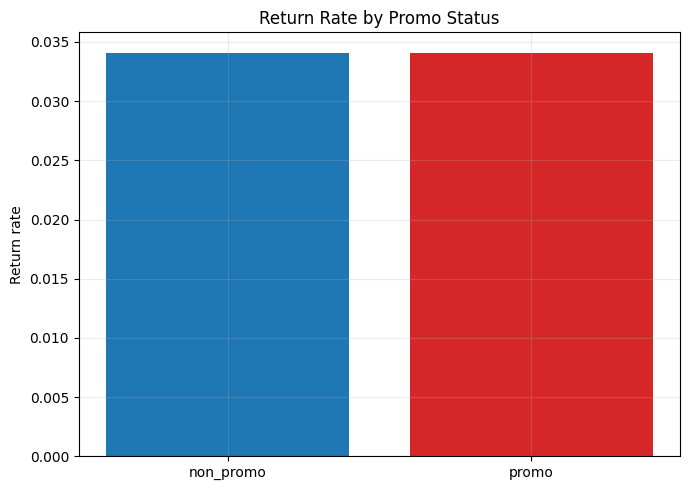

In [7]:
promo_return_summary = pd.DataFrame()

if not items_enriched.empty:
    promo_return_summary = items_enriched.groupby('promo_used').agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        return_line_count=('return_indicator', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        gross_revenue=('item_revenue_std', 'sum'),
        avg_discount_amount=('discount_amount_std', 'mean'),
        avg_discount_rate=('discount_rate_std', 'mean'),
    ).reset_index()
    promo_return_summary['return_rate'] = np.where(promo_return_summary['ordered_quantity'] > 0, promo_return_summary['returned_quantity'] / promo_return_summary['ordered_quantity'], np.nan)
    promo_return_summary['refund_to_revenue_ratio'] = np.where(promo_return_summary['gross_revenue'] > 0, promo_return_summary['refund_amount'] / promo_return_summary['gross_revenue'], np.nan)
    display(promo_return_summary)

    fig, ax = plt.subplots(figsize=(7, 5))
    labels = ['non_promo', 'promo']
    vals = promo_return_summary.sort_values('promo_used')['return_rate']
    ax.bar(labels, vals, color=['tab:blue', 'tab:red'])
    ax.set_title('Return Rate by Promo Status')
    ax.set_ylabel('Return rate')
    plt.tight_layout()
    plt.show()

## 8. Return Rate by Discount Level

Create discount groups and compare return rate, wrong-size ratio, changed-mind ratio, and refund pressure.

,discount_group,ordered_quantity,returned_quantity,refund_amount,gross_revenue,wrong_size_returns,changed_mind_returns,return_line_count,return_rate,wrong_size_ratio,changed_mind_ratio,refund_to_revenue_ratio
0,high_discount,399062,"13,640.0000","40,561,407.5600","1,305,806,208.9300",1732,860,4975,0.0342,0.3481,0.1729,0.0311
1,low_discount,398126,"13,796.0000","56,677,250.6500","1,828,424,869.1800",1797,882,5185,0.0347,0.3466,0.1701,0.0310
2,medium_discount,444851,"14,929.0000","70,805,631.4900","2,301,206,454.5200",1825,926,5276,0.0336,0.3459,0.1755,0.0308
3,no_discount,1971104,"67,236.0000","342,616,029.8900","10,995,039,052.9000",8612,4263,24503,0.0341,0.3515,0.1740,0.0312


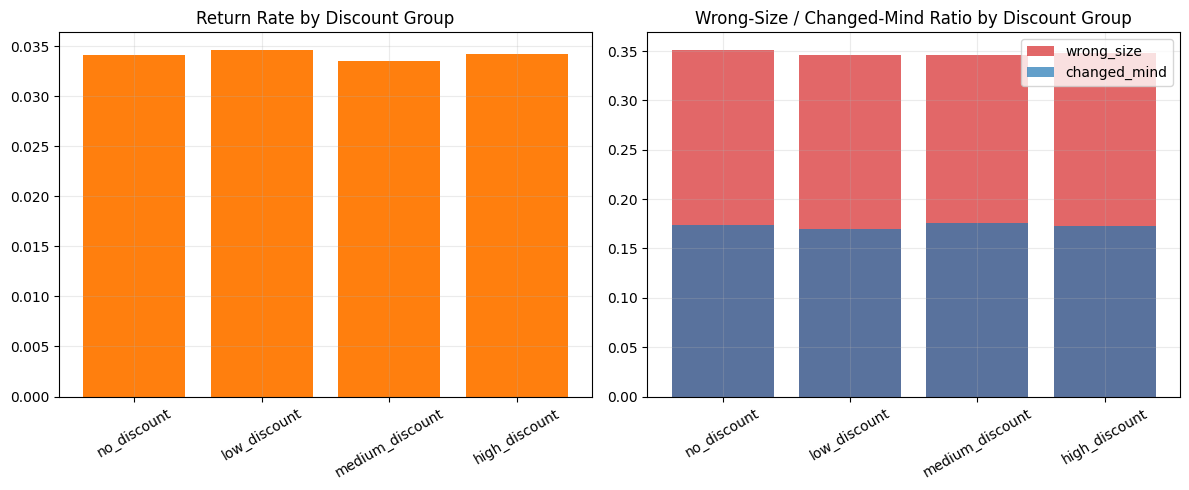

In [8]:
discount_summary = pd.DataFrame()

if not items_enriched.empty:
    q1 = items_enriched.loc[items_enriched['discount_rate_std'] > 0, 'discount_rate_std'].quantile(0.33)
    q2 = items_enriched.loc[items_enriched['discount_rate_std'] > 0, 'discount_rate_std'].quantile(0.67)

    def discount_group(x):
        if pd.isna(x) or x <= 0:
            return 'no_discount'
        if x <= q1:
            return 'low_discount'
        if x <= q2:
            return 'medium_discount'
        return 'high_discount'

    items_enriched['discount_group'] = items_enriched['discount_rate_std'].map(discount_group)
    items_enriched['wrong_size_flag'] = items_enriched['return_reason_std'].isin(['wrong_size', 'too_small', 'too_large', 'fit_issue'])
    items_enriched['changed_mind_flag'] = items_enriched['return_reason_std'].isin(['changed_mind'])

    discount_summary = items_enriched.groupby('discount_group').agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        gross_revenue=('item_revenue_std', 'sum'),
        wrong_size_returns=('wrong_size_flag', 'sum'),
        changed_mind_returns=('changed_mind_flag', 'sum'),
        return_line_count=('return_indicator', 'sum'),
    ).reset_index()
    discount_summary['return_rate'] = np.where(discount_summary['ordered_quantity'] > 0, discount_summary['returned_quantity'] / discount_summary['ordered_quantity'], np.nan)
    discount_summary['wrong_size_ratio'] = np.where(discount_summary['return_line_count'] > 0, discount_summary['wrong_size_returns'] / discount_summary['return_line_count'], np.nan)
    discount_summary['changed_mind_ratio'] = np.where(discount_summary['return_line_count'] > 0, discount_summary['changed_mind_returns'] / discount_summary['return_line_count'], np.nan)
    discount_summary['refund_to_revenue_ratio'] = np.where(discount_summary['gross_revenue'] > 0, discount_summary['refund_amount'] / discount_summary['gross_revenue'], np.nan)
    display(discount_summary)

    ordered = pd.Categorical(discount_summary['discount_group'], ['no_discount', 'low_discount', 'medium_discount', 'high_discount'])
    plot_df = discount_summary.assign(discount_group=pd.Series(ordered)).sort_values('discount_group')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].bar(plot_df['discount_group'].astype(str), plot_df['return_rate'], color='tab:orange')
    axes[0].set_title('Return Rate by Discount Group')
    axes[0].tick_params(axis='x', rotation=30)
    axes[1].bar(plot_df['discount_group'].astype(str), plot_df['wrong_size_ratio'], color='tab:red', alpha=0.7, label='wrong_size')
    axes[1].bar(plot_df['discount_group'].astype(str), plot_df['changed_mind_ratio'], color='tab:blue', alpha=0.7, label='changed_mind')
    axes[1].set_title('Wrong-Size / Changed-Mind Ratio by Discount Group')
    axes[1].legend()
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

## 9. Return Reason x Category Analysis

Summarize return reason mix within categories and display a heatmap-style matrix.

,category,return_reason_std,return_count,refund_amount,category_total,reason_share_within_category
0,Casual,changed_mind,228,"2,525,235.9700",1294,0.1762
1,Casual,defective,262,"2,875,267.7000",1294,0.2025
2,Casual,late_delivery,121,"1,394,106.1800",1294,0.0935
3,Casual,not_as_described,229,"2,274,630.5200",1294,0.1770
4,Casual,wrong_size,454,"4,957,854.0000",1294,0.3509
5,GenZ,changed_mind,349,"1,742,880.7700",2126,0.1642
6,GenZ,defective,429,"2,176,143.3500",2126,0.2018
7,GenZ,late_delivery,240,"1,169,932.0800",2126,0.1129
8,GenZ,not_as_described,376,"2,042,095.9000",2126,0.1769
9,GenZ,wrong_size,732,"4,018,718.1400",2126,0.3443


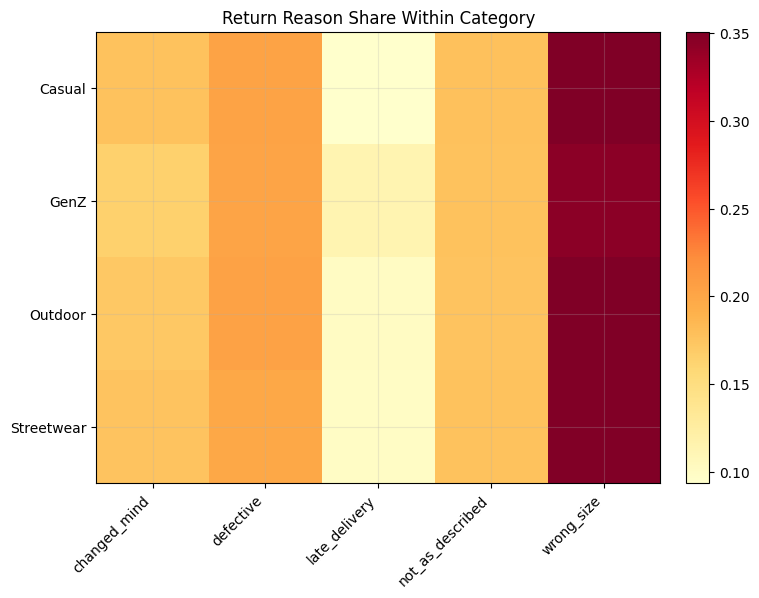

In [9]:
reason_category = pd.DataFrame()

if not items_enriched.empty and 'category' in items_enriched.columns and items_enriched['return_reason_std'].notna().any():
    reason_category = items_enriched[items_enriched['return_indicator']].groupby(['category', 'return_reason_std']).agg(
        return_count=('return_indicator', 'sum'),
        refund_amount=('refund_amount', 'sum'),
    ).reset_index()
    totals = reason_category.groupby('category')['return_count'].sum().rename('category_total')
    reason_category = reason_category.merge(totals, on='category', how='left')
    reason_category['reason_share_within_category'] = np.where(reason_category['category_total'] > 0, reason_category['return_count'] / reason_category['category_total'], np.nan)
    display(reason_category.head(20))

    top_categories = reason_category.groupby('category')['return_count'].sum().sort_values(ascending=False).head(8).index
    top_reasons = reason_category.groupby('return_reason_std')['return_count'].sum().sort_values(ascending=False).head(6).index
    pivot = reason_category[reason_category['category'].isin(top_categories) & reason_category['return_reason_std'].isin(top_reasons)].pivot(index='category', columns='return_reason_std', values='reason_share_within_category').fillna(0)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot.values, cmap='YlOrRd')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('Return Reason Share Within Category')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 10. Return Rate by Size and Category

Identify category x size combinations with the highest observed return risk.

,category,size,ordered_quantity,returned_quantity,return_count,refund_amount,return_rate
7,GenZ,XL,24049,906.0000,333,"2,395,077.1700",0.0377
6,GenZ,S,57642,"2,081.0000",743,"2,523,557.9000",0.0361
5,GenZ,M,46482,"1,670.0000",597,"3,441,080.4900",0.0359
10,Outdoor,S,250805,"8,907.0000",3211,"17,166,705.9500",0.0355
8,Outdoor,L,324360,"11,426.0000",4093,"21,301,987.5800",0.0352
9,Outdoor,M,318024,"10,805.0000",3976,"21,268,050.4500",0.0340
14,Streetwear,S,429397,"14,578.0000",5317,"93,438,310.6100",0.0339
12,Streetwear,L,398836,"13,511.0000",4990,"91,196,682.8800",0.0339
13,Streetwear,M,394881,"13,377.0000",4845,"85,887,714.6200",0.0339
15,Streetwear,XL,545712,"18,346.0000",6647,"136,243,231.9900",0.0336


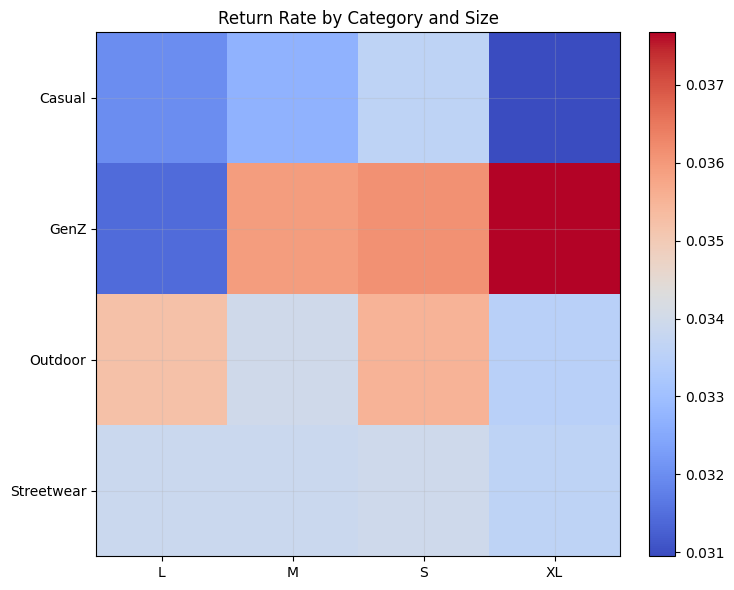

In [10]:
size_category = pd.DataFrame()

if not items_enriched.empty and 'size' in items_enriched.columns and 'category' in items_enriched.columns:
    size_category = items_enriched.groupby(['category', 'size']).agg(
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        return_count=('return_indicator', 'sum'),
        refund_amount=('refund_amount', 'sum'),
    ).reset_index()
    size_category['return_rate'] = np.where(size_category['ordered_quantity'] > 0, size_category['returned_quantity'] / size_category['ordered_quantity'], np.nan)
    display(size_category.sort_values('return_rate', ascending=False).head(20))

    pivot = size_category.pivot(index='category', columns='size', values='return_rate').fillna(0)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot.values, cmap='coolwarm')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('Return Rate by Category and Size')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    print('Size-level analysis unavailable because size is missing.')

## 11. Wrong-Size and Changed-Mind Deep Dive

Group wrong-size-like and changed-mind-like reasons and compare them across discount, promo, category, and size.

In [11]:
wrong_size_labels = ['wrong_size', 'too_small', 'too_large', 'fit_issue']
changed_mind_labels = ['changed_mind']
display(pd.DataFrame({
    'reason_group': ['wrong_size_like', 'changed_mind_like'],
    'labels': [', '.join(wrong_size_labels), ', '.join(changed_mind_labels)]
}))

deep_dive = pd.DataFrame()
if not items_enriched.empty:
    deep_dive = items_enriched[items_enriched['return_indicator']].copy()
    deep_dive['wrong_size_like'] = deep_dive['return_reason_std'].isin(wrong_size_labels)
    deep_dive['changed_mind_like'] = deep_dive['return_reason_std'].isin(changed_mind_labels)

    for group_col in ['discount_group', 'promo_used', 'category', 'size']:
        if group_col in deep_dive.columns:
            tmp = deep_dive.groupby(group_col).agg(
                return_lines=('return_indicator', 'sum'),
                wrong_size_like=('wrong_size_like', 'sum'),
                changed_mind_like=('changed_mind_like', 'sum'),
            ).reset_index()
            tmp['wrong_size_ratio'] = np.where(tmp['return_lines'] > 0, tmp['wrong_size_like'] / tmp['return_lines'], np.nan)
            tmp['changed_mind_ratio'] = np.where(tmp['return_lines'] > 0, tmp['changed_mind_like'] / tmp['return_lines'], np.nan)
            print(group_col)
            display(tmp.sort_values('return_lines', ascending=False).head(15))

,reason_group,labels
0,wrong_size_like,"wrong_size, too_small, too_large, fit_issue"
1,changed_mind_like,changed_mind


discount_group


,discount_group,return_lines,wrong_size_like,changed_mind_like,wrong_size_ratio,changed_mind_ratio
3,no_discount,24503,8612,4263,0.3515,0.1740
2,medium_discount,5276,1825,926,0.3459,0.1755
1,low_discount,5185,1797,882,0.3466,0.1701
0,high_discount,4975,1732,860,0.3481,0.1729


promo_used


,promo_used,return_lines,wrong_size_like,changed_mind_like,wrong_size_ratio,changed_mind_ratio
0,False,24503,8612,4263,0.3515,0.1740
1,True,15436,5354,2668,0.3469,0.1728


category


,category,return_lines,wrong_size_like,changed_mind_like,wrong_size_ratio,changed_mind_ratio
3,Streetwear,21799,7626,3830,0.3498,0.1757
2,Outdoor,14720,5154,2524,0.3501,0.1715
1,GenZ,2126,732,349,0.3443,0.1642
0,Casual,1294,454,228,0.3509,0.1762


size


,size,return_lines,wrong_size_like,changed_mind_like,wrong_size_ratio,changed_mind_ratio
3,XL,10655,3711,1859,0.3483,0.1745
1,M,9820,3482,1698,0.3546,0.1729
0,L,9741,3401,1719,0.3491,0.1765
2,S,9723,3372,1655,0.3468,0.1702


## 12. Product-Level Return Pressure

Identify products with high volume and high return or refund pressure, including promo-heavy products.

,product_id_std,product_name,category,size,ordered_quantity,returned_quantity,refund_amount,gross_revenue,promo_usage_rate,wrong_size_return_ratio,return_rate,refund_to_revenue_ratio
1322,1937,UrbanVN RP-12,Outdoor,M,1704,104.0000,"316,125.7300","5,535,019.8400",0.3743,0.0209,0.0610,0.0571
1516,2241,VietMotion RP-38,Outdoor,M,2023,112.0000,"106,518.7700","2,111,053.8400",0.1648,0.0406,0.0554,0.0505
1391,2058,UrbanVN UE-18,Streetwear,L,5863,307.0000,"844,742.9600","17,828,904.4100",0.3602,0.0303,0.0524,0.0474
1022,1496,VietMode RP-88,Outdoor,S,1772,92.0000,"371,073.4500","7,771,481.0300",0.3700,0.0200,0.0519,0.0477
1597,2412,VietMotion YY-21,GenZ,S,4701,236.0000,"258,322.1500","5,502,960.2800",0.3249,0.0198,0.0502,0.0469
1232,1819,SaigonCore YY-14,GenZ,XL,2194,108.0000,"293,509.5500","6,617,416.7600",0.3180,0.0280,0.0492,0.0444
1401,2074,UrbanVN UC-09,Streetwear,L,2049,98.0000,"338,608.5800","7,725,388.4000",0.3448,0.0237,0.0478,0.0438
398,589,SaigonFlex UC-54,Streetwear,M,2164,103.0000,"922,941.7900","20,487,497.2800",0.3983,0.0257,0.0476,0.0450
988,1454,VietMode RP-46,Outdoor,L,1746,83.0000,"367,731.9500","8,115,810.1400",0.4392,0.0238,0.0475,0.0453
611,945,HanoiStreet UC-08,Streetwear,M,3426,159.0000,"1,091,178.2100","26,220,259.0100",0.3627,0.0320,0.0464,0.0416


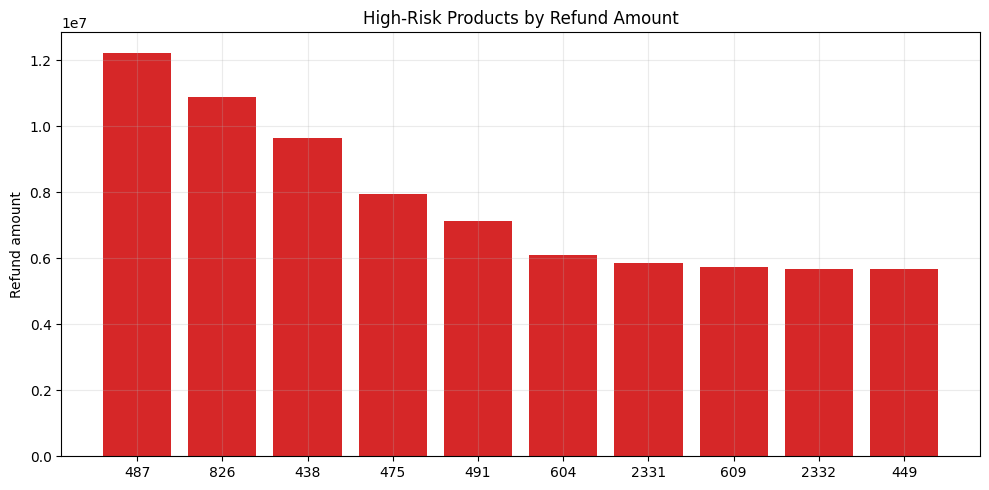

In [12]:
product_pressure = pd.DataFrame()

if not items_enriched.empty and 'product_id_std' in items_enriched.columns:
    product_pressure = items_enriched.groupby('product_id_std').agg(
        product_name=('product_name', 'first') if 'product_name' in items_enriched.columns else ('product_id_std', 'first'),
        category=('category', 'first') if 'category' in items_enriched.columns else ('product_id_std', 'first'),
        size=('size', 'first') if 'size' in items_enriched.columns else ('product_id_std', 'first'),
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        gross_revenue=('item_revenue_std', 'sum'),
        promo_usage_rate=('promo_used', 'mean'),
        wrong_size_return_ratio=('wrong_size_flag', 'mean') if 'wrong_size_flag' in items_enriched.columns else ('promo_used', 'mean'),
    ).reset_index()
    product_pressure['return_rate'] = np.where(product_pressure['ordered_quantity'] > 0, product_pressure['returned_quantity'] / product_pressure['ordered_quantity'], np.nan)
    product_pressure['refund_to_revenue_ratio'] = np.where(product_pressure['gross_revenue'] > 0, product_pressure['refund_amount'] / product_pressure['gross_revenue'], np.nan)
    high_risk_products = product_pressure[(product_pressure['ordered_quantity'] >= product_pressure['ordered_quantity'].quantile(0.75))].sort_values(['return_rate', 'refund_amount'], ascending=False).head(20)
    display(high_risk_products)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = product_pressure.sort_values('refund_amount', ascending=False).head(10)
    ax.bar(plot_df['product_id_std'].astype(str), plot_df['refund_amount'], color='tab:red')
    ax.set_title('High-Risk Products by Refund Amount')
    ax.set_ylabel('Refund amount')
    plt.tight_layout()
    plt.show()

## 13. Return and Promotion Over Time

Aggregate return pressure over time and compare promo vs non-promo return pressure when possible.

,date,gross_revenue,refund_amount,ordered_quantity,returned_quantity,promo_returned_quantity,nonpromo_returned_quantity,wrong_size_returns,changed_mind_returns,return_rate,promo_return_rate,nonpromo_return_rate,wrong_size_return_ratio,changed_mind_return_ratio
0,2012-07-04,"5,123,547.9400","171,067.0100",777,26.0000,0.0000,26.0000,3,6,0.0335,0.0000,0.0335,0.1154,0.2308
1,2012-07-05,"2,751,773.4500","57,342.9100",428,15.0000,0.0000,15.0000,3,1,0.0350,0.0000,0.0350,0.2000,0.0667
2,2012-07-06,"3,054,029.4200","195,614.5800",441,28.0000,0.0000,28.0000,3,2,0.0635,0.0000,0.0635,0.1071,0.0714
3,2012-07-07,"2,667,930.9400","134,785.1400",364,14.0000,0.0000,14.0000,0,1,0.0385,0.0000,0.0385,0.0000,0.0714
4,2012-07-08,"2,360,851.9000","135,871.8300",394,21.0000,0.0000,21.0000,5,1,0.0533,0.0000,0.0533,0.2381,0.0476
5,2012-07-09,"3,548,386.4600","165,093.1600",730,39.0000,0.0000,39.0000,5,2,0.0534,0.0000,0.0534,0.1282,0.0513
6,2012-07-10,"5,234,938.6200","112,143.0700",928,33.0000,0.0000,33.0000,5,3,0.0356,0.0000,0.0356,0.1515,0.0909
7,2012-07-11,"5,582,884.7800","173,779.7300",1097,36.0000,0.0000,36.0000,3,0,0.0328,0.0000,0.0328,0.0833,0.0000
8,2012-07-12,"5,734,632.0200","94,601.9700",1241,17.0000,0.0000,17.0000,4,2,0.0137,0.0000,0.0137,0.2353,0.1176
9,2012-07-13,"5,309,511.7100","56,152.8700",995,10.0000,0.0000,10.0000,3,0,0.0101,0.0000,0.0101,0.3000,0.0000


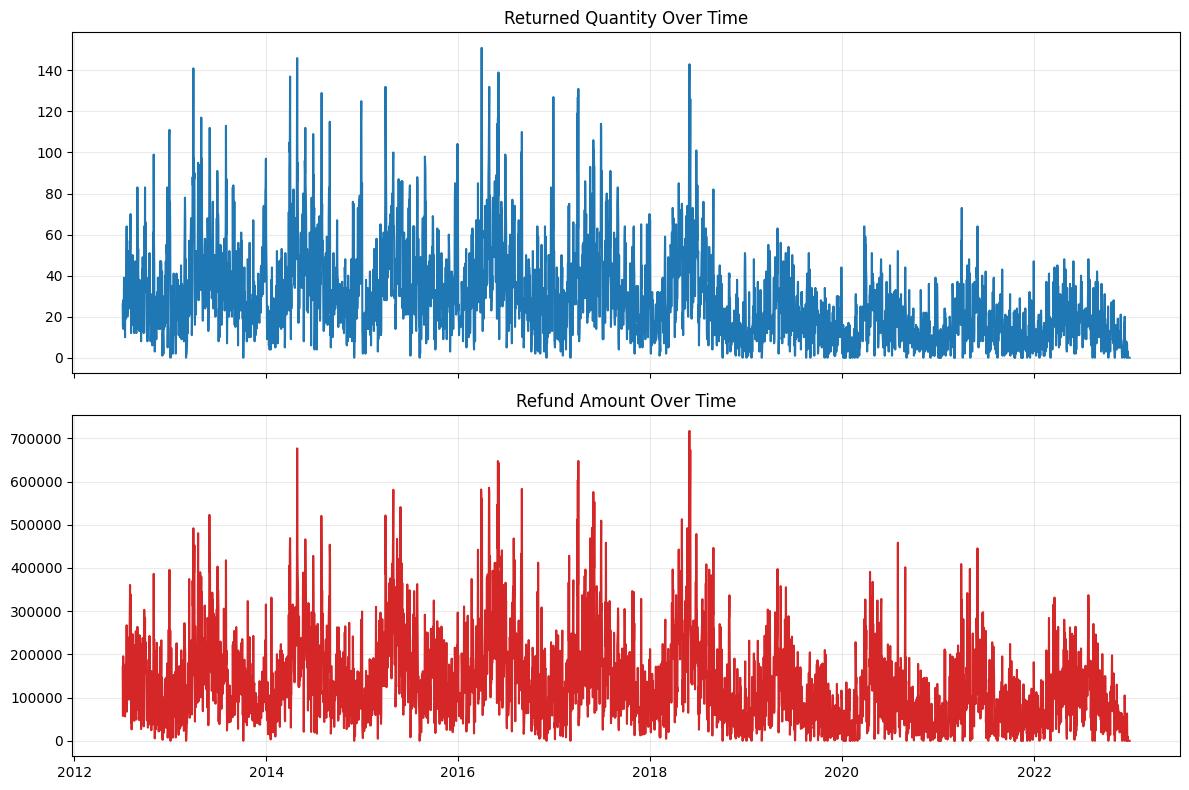

In [13]:
time_series = pd.DataFrame()

if not items_enriched.empty and items_enriched['order_date_std'].notna().any():
    ts = items_enriched.copy()
    ts['date'] = ts['order_date_std'].dt.floor('D')
    time_series = ts.groupby('date').agg(
        gross_revenue=('item_revenue_std', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        ordered_quantity=('ordered_quantity', 'sum'),
        returned_quantity=('returned_quantity', 'sum'),
        promo_returned_quantity=('returned_quantity', lambda s: s[ts.loc[s.index, 'promo_used']].sum()),
        nonpromo_returned_quantity=('returned_quantity', lambda s: s[~ts.loc[s.index, 'promo_used']].sum()),
        wrong_size_returns=('wrong_size_flag', 'sum') if 'wrong_size_flag' in ts.columns else ('promo_used', 'sum'),
        changed_mind_returns=('changed_mind_flag', 'sum') if 'changed_mind_flag' in ts.columns else ('promo_used', 'sum'),
    ).reset_index()
    time_series['return_rate'] = np.where(time_series['ordered_quantity'] > 0, time_series['returned_quantity'] / time_series['ordered_quantity'], np.nan)
    time_series['promo_return_rate'] = np.where(time_series['ordered_quantity'] > 0, time_series['promo_returned_quantity'] / time_series['ordered_quantity'], np.nan)
    time_series['nonpromo_return_rate'] = np.where(time_series['ordered_quantity'] > 0, time_series['nonpromo_returned_quantity'] / time_series['ordered_quantity'], np.nan)
    time_series['wrong_size_return_ratio'] = np.where(time_series['returned_quantity'] > 0, time_series['wrong_size_returns'] / time_series['returned_quantity'], np.nan)
    time_series['changed_mind_return_ratio'] = np.where(time_series['returned_quantity'] > 0, time_series['changed_mind_returns'] / time_series['returned_quantity'], np.nan)
    display(time_series.head(12))

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(time_series['date'], time_series['returned_quantity'], color='tab:blue')
    axes[0].set_title('Returned Quantity Over Time')
    axes[1].plot(time_series['date'], time_series['refund_amount'], color='tab:red')
    axes[1].set_title('Refund Amount Over Time')
    plt.tight_layout()
    plt.show()

## 14. Net Revenue Context

Compare gross Revenue, refund pressure, and net Revenue overall and by promo/category context where possible.

In [14]:
net_context = pd.DataFrame()

if not items_enriched.empty:
    net_context = items_enriched.groupby('promo_used').agg(
        gross_revenue=('item_revenue_std', 'sum'),
        refund_amount=('refund_amount', 'sum'),
        net_revenue=('net_revenue_std', 'sum'),
    ).reset_index()
    net_context['refund_to_revenue_ratio'] = np.where(net_context['gross_revenue'] > 0, net_context['refund_amount'] / net_context['gross_revenue'], np.nan)
    display(net_context)

    if 'category' in items_enriched.columns:
        category_net = items_enriched.groupby('category').agg(
            gross_revenue=('item_revenue_std', 'sum'),
            refund_amount=('refund_amount', 'sum'),
            net_revenue=('net_revenue_std', 'sum'),
        ).reset_index()
        category_net['refund_to_revenue_ratio'] = np.where(category_net['gross_revenue'] > 0, category_net['refund_amount'] / category_net['gross_revenue'], np.nan)
        display(category_net.sort_values('refund_to_revenue_ratio', ascending=False).head(15))

,promo_used,gross_revenue,refund_amount,net_revenue,refund_to_revenue_ratio
0,False,"10,995,039,052.9000","342,616,029.8900","10,652,423,023.0100",0.0312
1,True,"5,435,437,532.6300","168,044,289.7000","5,267,393,242.9300",0.0309


,category,gross_revenue,refund_amount,net_revenue,refund_to_revenue_ratio
1,GenZ,"343,599,095.3600","11,149,770.2400","332,449,325.1200",0.0324
2,Outdoor,"2,494,882,754.2000","78,717,514.8800","2,416,165,239.3200",0.0316
3,Streetwear,"13,131,346,352.6200","406,765,940.1000","12,724,580,412.5200",0.0310
0,Casual,"460,648,383.3500","14,027,094.3700","446,621,288.9800",0.0305


## 15. Business Recommendation Insights

Translate the observed return, discount, promo, category, and size patterns into practical business recommendations.

In [15]:
if not discount_summary.empty:
    high_disc = discount_summary[discount_summary['discount_group'] == 'high_discount']
    if not high_disc.empty:
        print('High-discount return context')
        display(high_disc)

if not size_category.empty:
    print('Highest-risk category x size combinations')
    display(size_category.sort_values('return_rate', ascending=False).head(15))

if not product_pressure.empty:
    print('Products with highest refund-to-revenue pressure')
    display(product_pressure.sort_values('refund_to_revenue_ratio', ascending=False).head(15))

High-discount return context


,discount_group,ordered_quantity,returned_quantity,refund_amount,gross_revenue,wrong_size_returns,changed_mind_returns,return_line_count,return_rate,wrong_size_ratio,changed_mind_ratio,refund_to_revenue_ratio
0,high_discount,399062,"13,640.0000","40,561,407.5600","1,305,806,208.9300",1732,860,4975,0.0342,0.3481,0.1729,0.0311


Highest-risk category x size combinations


,category,size,ordered_quantity,returned_quantity,return_count,refund_amount,return_rate
7,GenZ,XL,24049,906.0000,333,"2,395,077.1700",0.0377
6,GenZ,S,57642,"2,081.0000",743,"2,523,557.9000",0.0361
5,GenZ,M,46482,"1,670.0000",597,"3,441,080.4900",0.0359
10,Outdoor,S,250805,"8,907.0000",3211,"17,166,705.9500",0.0355
8,Outdoor,L,324360,"11,426.0000",4093,"21,301,987.5800",0.0352
9,Outdoor,M,318024,"10,805.0000",3976,"21,268,050.4500",0.0340
14,Streetwear,S,429397,"14,578.0000",5317,"93,438,310.6100",0.0339
12,Streetwear,L,398836,"13,511.0000",4990,"91,196,682.8800",0.0339
13,Streetwear,M,394881,"13,377.0000",4845,"85,887,714.6200",0.0339
15,Streetwear,XL,545712,"18,346.0000",6647,"136,243,231.9900",0.0336


Products with highest refund-to-revenue pressure


,product_id_std,product_name,category,size,ordered_quantity,returned_quantity,refund_amount,gross_revenue,promo_usage_rate,wrong_size_return_ratio,return_rate,refund_to_revenue_ratio
119,234,LotusWear UR-06,Streetwear,L,7,6.0000,"26,888.1200","36,676.4800",0.0000,0.5000,0.8571,0.7331
1475,2175,PhoenixWear UC-05,Streetwear,XL,4,3.0000,"16,235.3700","22,774.7200",0.0000,0.0000,0.7500,0.7129
695,1064,MekongFit RP-10,Outdoor,S,9,4.0000,"7,697.7700","16,344.3900",0.5000,0.0000,0.4444,0.4710
1164,1732,SaigonCore RP-01,Outdoor,S,10,5.0000,"22,729.7100","48,493.5100",1.0000,0.5000,0.5000,0.4687
694,1063,MekongFit RP-09,Outdoor,XL,6,3.0000,"5,134.3400","11,131.3400",0.5000,0.0000,0.5000,0.4613
1558,2356,VietMotion UC-04,Streetwear,S,5,2.0000,"14,412.6300","36,414.3500",1.0000,0.0000,0.4000,0.3958
876,1309,VietMode RP-01,Outdoor,M,8,3.0000,"8,844.6100","23,565.1600",0.5000,0.0000,0.3750,0.3753
1108,1653,VietMode RS-91,Outdoor,M,8,3.0000,"13,800.6900","38,179.2400",0.0000,0.0000,0.3750,0.3615
676,1042,MekongStyle UC-14,Streetwear,L,11,4.0000,"56,502.3700","157,687.3200",0.0000,0.0000,0.3636,0.3583
1548,2340,VietMotion UE-14,Streetwear,S,13,4.0000,"21,345.0600","72,421.9900",0.0000,0.0000,0.3077,0.2947


## 16. Leakage-Safe Return/Refund Feature Preview

Create lagged historical return and refund features. These are more appropriate for net-Revenue forecasting than gross-Revenue forecasting.

In [16]:
feature_preview = pd.DataFrame()

if not time_series.empty:
    feat = time_series.copy().sort_values('date')
    feat['net_revenue'] = feat['gross_revenue'] - feat['refund_amount']
    feat['refund_to_revenue_ratio'] = np.where(feat['gross_revenue'] > 0, feat['refund_amount'] / feat['gross_revenue'], np.nan)
    feat['return_rate_lag_30'] = feat['return_rate'].shift(30)
    feat['refund_amount_lag_30'] = feat['refund_amount'].shift(30)
    feat['return_quantity_lag_30'] = feat['returned_quantity'].shift(30)
    feat['wrong_size_return_ratio_lag_30'] = feat['wrong_size_return_ratio'].shift(30)
    feat['changed_mind_return_ratio_lag_30'] = feat['changed_mind_return_ratio'].shift(30)
    feat['promo_return_rate_lag_30'] = feat['promo_return_rate'].shift(30)
    feat['refund_to_revenue_ratio_lag_30'] = feat['refund_to_revenue_ratio'].shift(30)
    feat['defective_return_ratio_lag_30'] = np.nan

    preview_cols = [
        'date', 'gross_revenue', 'net_revenue', 'return_rate', 'refund_amount',
        'returned_quantity', 'promo_return_rate', 'nonpromo_return_rate',
        'wrong_size_return_ratio', 'changed_mind_return_ratio', 'return_rate_lag_30',
        'refund_amount_lag_30', 'return_quantity_lag_30', 'wrong_size_return_ratio_lag_30',
        'defective_return_ratio_lag_30', 'promo_return_rate_lag_30', 'refund_to_revenue_ratio_lag_30'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('Future return, refund, and return-reason values must not be used directly unless they are genuinely known before prediction.')

,date,gross_revenue,net_revenue,return_rate,refund_amount,returned_quantity,promo_return_rate,nonpromo_return_rate,wrong_size_return_ratio,changed_mind_return_ratio,return_rate_lag_30,refund_amount_lag_30,return_quantity_lag_30,wrong_size_return_ratio_lag_30,defective_return_ratio_lag_30,promo_return_rate_lag_30,refund_to_revenue_ratio_lag_30
0,2012-07-04,"5,123,547.9400","4,952,480.9300",0.0335,"171,067.0100",26.0000,0.0000,0.0335,0.1154,0.2308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500","2,694,430.5400",0.0350,"57,342.9100",15.0000,0.0000,0.0350,0.2000,0.0667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200","2,858,414.8400",0.0635,"195,614.5800",28.0000,0.0000,0.0635,0.1071,0.0714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400","2,533,145.8000",0.0385,"134,785.1400",14.0000,0.0000,0.0385,0.0000,0.0714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000","2,224,980.0700",0.0533,"135,871.8300",21.0000,0.0000,0.0533,0.2381,0.0476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600","3,383,293.3000",0.0534,"165,093.1600",39.0000,0.0000,0.0534,0.1282,0.0513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200","5,122,795.5500",0.0356,"112,143.0700",33.0000,0.0000,0.0356,0.1515,0.0909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800","5,409,105.0500",0.0328,"173,779.7300",36.0000,0.0000,0.0328,0.0833,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200","5,640,030.0500",0.0137,"94,601.9700",17.0000,0.0000,0.0137,0.2353,0.1176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100","5,253,358.8400",0.0101,"56,152.8700",10.0000,0.0000,0.0101,0.3000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Future return, refund, and return-reason values must not be used directly unless they are genuinely known before prediction.


## 17. Key Observations and Warnings

Summarize whether promo or discount-heavy items show more return pressure, where size/category risk concentrates, and which lagged features look most useful for net-Revenue forecasting.

In [17]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not promo_return_summary.empty:
    promo_rate = promo_return_summary.loc[promo_return_summary['promo_used'] == True, 'return_rate']
    nonpromo_rate = promo_return_summary.loc[promo_return_summary['promo_used'] == False, 'return_rate']
    if not promo_rate.empty and not nonpromo_rate.empty:
        relation = 'higher' if promo_rate.iloc[0] > nonpromo_rate.iloc[0] else 'lower'
        summary_lines.append(f'- Promoted items show {relation} return rate than non-promoted items ({promo_rate.iloc[0]:.2%} vs {nonpromo_rate.iloc[0]:.2%}).')

if not discount_summary.empty:
    high_disc = discount_summary.loc[discount_summary['discount_group'] == 'high_discount']
    no_disc = discount_summary.loc[discount_summary['discount_group'] == 'no_discount']
    if not high_disc.empty and not no_disc.empty:
        summary_lines.append(f"- High-discount groups show return rate {high_disc['return_rate'].iloc[0]:.2%} vs no-discount {no_disc['return_rate'].iloc[0]:.2%}.")
        summary_lines.append(f"- High-discount wrong-size ratio {high_disc['wrong_size_ratio'].iloc[0]:.2%} and changed-mind ratio {high_disc['changed_mind_ratio'].iloc[0]:.2%}.")

if not size_category.empty:
    top_combo = size_category.sort_values('return_rate', ascending=False).head(5)
    summary_lines.append('- Categories and sizes with highest return risk: ' + ', '.join(f"{r.category}/{r.size} ({r.return_rate:.2%})" for r in top_combo.itertuples()) + '.')

if not reason_category.empty:
    top_patterns = reason_category.sort_values('reason_share_within_category', ascending=False).head(5)
    summary_lines.append('- Category x return reason patterns: ' + ', '.join(f"{r.category}:{r.return_reason_std} ({r.reason_share_within_category:.2%})" for r in top_patterns.itertuples()) + '.')

if not deep_dive.empty:
    wrong_size_cat = deep_dive.groupby('category')['wrong_size_like'].mean().sort_values(ascending=False).head(3) if 'category' in deep_dive.columns else pd.Series(dtype=float)
    changed_disc = discount_summary.sort_values('changed_mind_ratio', ascending=False).head(2) if not discount_summary.empty else pd.DataFrame()
    if not wrong_size_cat.empty:
        summary_lines.append('- Wrong-size concentration patterns: ' + ', '.join(f"{idx} ({val:.2%})" for idx, val in wrong_size_cat.items()) + '.')
    if not changed_disc.empty:
        summary_lines.append('- Changed-mind concentration patterns by discount: ' + ', '.join(f"{r.discount_group} ({r.changed_mind_ratio:.2%})" for r in changed_disc.itertuples()) + '.')

if not product_pressure.empty:
    top_products = product_pressure.sort_values('refund_amount', ascending=False).head(5)
    summary_lines.append('- Products with high return/refund pressure: ' + ', '.join(f"{r.product_id_std} ({r.refund_amount:,.2f})" for r in top_products.itertuples()) + '.')

if not net_context.empty:
    promo_net = net_context.loc[net_context['promo_used'] == True, 'refund_to_revenue_ratio']
    nonpromo_net = net_context.loc[net_context['promo_used'] == False, 'refund_to_revenue_ratio']
    if not promo_net.empty and not nonpromo_net.empty:
        summary_lines.append(f'- Returns affect net Revenue, with promo refund-to-revenue ratio {promo_net.iloc[0]:.2%} vs non-promo {nonpromo_net.iloc[0]:.2%}.')

summary_lines.append('- Practical business recommendations: improve sizing guidance for high-risk category/size combinations; review discount strategy where changed-mind ratios are elevated; monitor promo-heavy products with high refund-to-revenue ratio; review product descriptions and quality for categories where wrong-size or not-as-described returns dominate.')

quality_notes = []
if returns_clean is not None:
    unmatched = 0
    if 'return_merge' in items_enriched.columns:
        unmatched = int((items_enriched['return_merge'] == 'left_only').sum())
    quality_notes.append(f'return item match strategy: exact order_id + product_id where available')
    if unmatched:
        quality_notes.append(f'{unmatched} item rows have no matched return record')
if not items_enriched.empty:
    qty_issue = int((items_enriched['returned_quantity'] > items_enriched['ordered_quantity']).sum())
    if qty_issue:
        quality_notes.append(f'{qty_issue} lines have returned quantity greater than ordered quantity')
    promo_discount_mismatch = int(((items_enriched['promo_used']) & (items_enriched['discount_amount_std'].fillna(0).eq(0))).sum())
    discount_no_promo = int(((items_enriched['discount_amount_std'].fillna(0).gt(0)) & (~items_enriched['promo_id_std'].notna())).sum())
    quality_notes.append(f'{promo_discount_mismatch} lines have promo id but zero discount')
    quality_notes.append(f'{discount_no_promo} lines have discount > 0 but no promo id')

if quality_notes:
    summary_lines.append('- Return/promo/size data quality warnings: ' + '; '.join(map(str, quality_notes)))
else:
    summary_lines.append('- Return/promo/size data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended lagged return/refund features for net-Revenue forecasting: return_rate_lag_30, refund_amount_lag_30, return_quantity_lag_30, wrong_size_return_ratio_lag_30, changed_mind_return_ratio_lag_30, promo_return_rate_lag_30, and refund_to_revenue_ratio_lag_30.')
summary_lines.append('- Future return, refund, and return-reason values must not be used directly unless they are genuinely known before prediction.')
summary_lines.append('- Causal caution: these are observational associations and can reflect product mix, campaign targeting, size availability, seasonality, and quality differences.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Promoted items show lower return rate than non-promoted items (3.41% vs 3.41%).
- High-discount groups show return rate 3.42% vs no-discount 3.41%.
- High-discount wrong-size ratio 34.81% and changed-mind ratio 17.29%.
- Categories and sizes with highest return risk: GenZ/XL (3.77%), GenZ/S (3.61%), GenZ/M (3.59%), Outdoor/S (3.55%), Outdoor/L (3.52%).
- Category x return reason patterns: Casual:wrong_size (35.09%), Outdoor:wrong_size (35.01%), Streetwear:wrong_size (34.98%), GenZ:wrong_size (34.43%), Outdoor:defective (20.37%).
- Wrong-size concentration patterns: Casual (35.09%), Outdoor (35.01%), Streetwear (34.98%).
- Changed-mind concentration patterns by discount: medium_discount (17.55%), no_discount (17.40%).
- Products with high return/refund pressure: 487 (12,241,878.26), 826 (10,879,460.50), 438 (9,654,909.83), 475 (7,958,581.64), 491 (7,121,041.39).
- Returns affect net Revenue, with promo refund-to-revenue ratio 3.09% vs non-promo 3.12%.
- P